# Statystyczna Analiza Danych
Projekt zaliczeniowy

Analiza eksploracyjna zbioru danych sprzedażowych Superstore.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

np.random.seed(77)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

## Etap 1 - Wczytanie i wstępny przegląd


In [42]:
df = pd.read_excel("data/superstore.xls", engine="xlrd")
print(f"DF shape: {df.shape}")
df.head()

DF shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [44]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,NaN,NaN,4,793,793,3,1,531,49,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,NaN,NaN,5968,37,37,5191,9994,915,2001,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
min,1.000000,NaN,2014-01-03 00:00:00,2014-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,2015-05-23 00:00:00,2015-05-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,2016-06-26 00:00:00,2016-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,2017-05-14 00:00:00,2017-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000
max,9994.000000,NaN,2017-12-30 00:00:00,2018-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99301.000000,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000


In [45]:
from skimpy import skim

skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 9994   │ │ string      │ 13    │                                                          │
│ │ Number of columns │ 21     │ │ int64       │ 3     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 3     │                                                          │
│                                │ datetime64  │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column         ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │ Row ID         │   0 │      0 │     4998 │     2885 │      1 │   2499 │   4998 │   7496 │   9994 │ ▇▇▇▇▇▇  │  │
│ │ Postal Code    │   0 │      0 │    55190 │    32060 │   1040 │  23220 │  56430 │  90010 │  99300 │ ▅▅▃▂▃▇  │  │
│ │ Sales          │   0 │      0 │    229.9 │    623.2 │  0.444 │  17.28 │  54.49 │  209.9 │  22640 │    ▇    │  │
│ │ Quantity       │   0 │      0 │     3.79 │    2.225 │      1 │      2 │      3 │      5 │     14 │  ▇▃▂▁   │  │
│ │ Discount       │   0 │      0 │   0.1562 │   0.2065 │      0 │      0 │    0.2 │    0.2 │    0.8 │ ▇▆   ▁  │  │
│ │ Profit         │   0 │      0 │    28.66 │    234.3 │  -6600 │  1.729 │  8.666 │  29.36 │   8400 │     ▇   │  │
│ └────────────────┴─────┴────────┴──────────┴──────────┴────────┴────────┴────────┴────────┴────────┴─────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column               ┃ NA     ┃ NA %      ┃ first                ┃ last                ┃ frequency         ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩  │
│ │ Order Date           │      0 │         0 │      2014-01-03      │     2017-12-30      │ None              │  │
│ │ Ship Date            │      0 │         0 │      2014-01-07      │     2018-01-05      │ None              │  │
│ └──────────────────────┴────────┴───────────┴──────────────────────┴─────────────────────┴───────────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ Order ID  │  0 │    0 │ CA-2016-1 │ CA-2016-1 │ CA-2014-1 │ US-2017-1 │        14 │         1 │       9994 │  │
│ │           │    │      │ 52156     │ 52156     │ 0000

Opis kolumn:

- Zakładamy, że nie będziemy rozważać zakupów konkretnych artykułów (jest ich 1862), ani zakupów dokonywanych przez konkretnych klientów (jest ich 793). Takie założenie pozwala pominąć w analizie następujące kolumny:  'Customer ID', 'Customer Name', 'Product ID', 'Product Name'
- Nie będziemy również rozważać jakie artykuły były zamawiane razem, w jednym zamówieniu. Pomijamy kolumnę 'Order ID'.
- Ponadto pomijamy w analizie kolumnę, która nie wnosi istotnej statystycznie wartości: 'Row ID'
- W kolumnie 'Country' występuje tylko 1 wartość (tylko USA), więc jako niezmienna ma ona niewielką wartość statystyczną
- Informacja geograficzna występuje w zbiorze na czterech poziomach szczegółowości: 'Postal Code', 'City' (531 wartości), 'State' (49) i 'Region' (4). Poziomy te są wzajemnie nadmiarowe (kod pocztowy wyznacza miasto, miasto stan, stan region), więc do analizy wystarczy jeden z nich. Do testów statystycznych stosowanych w tym projekcie (tabele krzyżowe, porównania grup) nadaje się tylko poziom najgrubszy - 'Region': przy 531 miastach czy 49 stanach grupy liczyłyby po kilka obserwacji, a tabele krzyżowe nie spełniałyby warunku minimalnej liczebności oczekiwanej. Usuwamy więc 'Postal Code', 'City' i 'State', a zostawiamy 'Region'
- Kolumna 'Sub-Category' jest w pełni zagnieżdżona w 'Category' (każda z 17 podkategorii należy do dokładnie jednej z 3 kategorii). Analizę różnic między asortymentami prowadzimy na poziomie kategorii - schodzenie na poziom podkategorii oznaczałoby 136 par porównań dla każdej zmiennej numerycznej, co po korekcie Bonferroniego praktycznie odebrałoby testom moc. Usuwamy 'Sub-Category'. 
- Daty: 'Order Date', 'Ship Date'
- Kategoryczne: 'Ship Mode', 'Segment', 'Region', 'Category'
- Numeryczne: 'Sales', 'Quantity', 'Discount', 'Profit'

## Etap 2 - Czyszczenie danych

### 2.1 Analiza braków

Z opisów zmiennych wygenerowanych w Etapie 1. widać, że żadna zmienna nie ma braków (wszystkie kolumny mają po 9994 wartości), ale poniżej jeszcze bezpośrednio potwierdzamy to spostrzeżenie.

In [46]:
missing = df.isna().sum()
print(f"Number of missings in columns:\n{missing}")
print(missing[missing > 0] if missing.sum() > 0 else "There are no missings (in any column).\n")

empty = (df.astype(str).apply(lambda s: s.str.strip() == "")).sum()
print("Empty strings in columns:")
print(empty[empty > 0] if empty.sum() > 0 else "Empty strings not detected.")



Number of missings in columns:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
There are no missings (in any column).

Empty strings in columns:
Empty strings not detected.


Wniosek: w zbiorze nie ma żadnych braków - ani NaN, ani pustych stringów. Imputacja nie jest potrzebna.

Gdyby braki wystąpiły, potencjalnie możnaby zastosować:
- SimpleImputer(strategy="median") dla zmiennych ciągłych
- SimpleImputer(strategy="most_frequent") dla zmiennych kategorycznych
- KNNImputer (n_neighbors=6)  dla zmiennych ciągłych


### 2.2 Usunięcie duplikatów

In [47]:
# we are looking for duplicates, after dropping column "Row ID" (which causes forced uniqueness of each row)
columns_without_row_id = df.columns.drop("Row ID")
mask_dup = df.duplicated(subset=columns_without_row_id, keep=False)
print(f"Duplicated rows (counting also originals): {mask_dup.sum()}")
print(df.loc[mask_dup])

# keep only the 1st occurrence
before = len(df)
df = df.drop_duplicates(subset=columns_without_row_id, keep="first").reset_index(drop=True)
print(f"Deleted {before - len(df)} duplicates. Rows: {before} -> {len(df)}")

Duplicated rows (counting also originals): 2
      Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID   Customer Name      Segment        Country      City State  Postal Code Region       Product ID   Category  \
3405    3406  US-2014-150119 2014-04-23 2014-04-27  Standard Class    LB-16795  Laurel Beltran  Home Office  United States  Columbus  Ohio        43229   East  FUR-CH-10002965  Furniture   
3406    3407  US-2014-150119 2014-04-23 2014-04-27  Standard Class    LB-16795  Laurel Beltran  Home Office  United States  Columbus  Ohio        43229   East  FUR-CH-10002965  Furniture   

     Sub-Category                                       Product Name    Sales  Quantity  Discount   Profit  
3405       Chairs  Global Leather Highback Executive Chair with P...  281.372         2       0.3 -12.0588  
3406       Chairs  Global Leather Highback Executive Chair with P...  281.372         2       0.3 -12.0588  
Deleted 1 duplicates. Rows: 9994 -> 9993


### 2.3 Naprawa danych kolumny 'Postal Code'

Postal Code wczytał się jako int64, przez co kody niektórych stanów straciły wiodące zera (np. Massachusetts 01040 -> 1040).

Kolumna 'Postal Code' i tak zostanie usunięta, jako niosąca niemal tą samą informację, co 'City', ale dla celów demonstracyjnych poniższy kod czyści dane w tej kolumnie (uzupełnia brakujące zero).

In [48]:
# restore leading zeros (US ZIP always has 5 digits)
df["Postal Code"] = df["Postal Code"].astype(str).str.zfill(5)
print(f"After fix: {df.loc[df['Postal Code'].str.startswith('0'), 'Postal Code'].unique()[:5]}")


After fix: ['06824' '07090' '07960' '07109' '08701']


### 2.4 Przekształcanie kolumn

Tworzymy nową cechę "Handling Time", ponieważ potencjalnie może ona wnieść coś istotnego do analizy. Reprezentuje ona czas obsługi zamówienia, tzn. liczbę dni między datą zamówienia, a datą wysyłki. 

In [49]:
# create handling time (days between order and shipment)
df["Handling Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

### 2.5 Usuwamy kolumny zbędne (uzasadnienie zamieszczone jest pod koniec Etapu 1). 
Kolumnę "Ship Date" usuwamy, ponieważ w połączeniu z "Order Date" niesie tę samą informację co nowa zmienna "Handling Time".

In [50]:
columns_to_drop = ["Row ID", "Order ID", "Customer ID", "Customer Name",
                    "Product ID", "Product Name", "Postal Code", "Country", "Ship Date",
                    "Postal Code", "City", "State", "Sub-Category"]
df = df.drop(columns=columns_to_drop)
print(f"DF shape after transform & drop: {df.shape}")

# list of numeric variables
numeric_columns = ["Sales", "Profit", "Discount", "Quantity", "Handling Time"]
# list of categorical variables
categorical_columns = ["Category", "Segment", "Region", "Ship Mode"]

df.head()

DF shape after transform & drop: (9993, 10)


,Order Date,Ship Mode,Segment,Region,Category,Sales,Quantity,Discount,Profit,Handling Time
0,2016-11-08,Second Class,Consumer,South,Furniture,261.9600,2,0.00,41.9136,3
1,2016-11-08,Second Class,Consumer,South,Furniture,731.9400,3,0.00,219.5820,3
2,2016-06-12,Second Class,Corporate,West,Office Supplies,14.6200,2,0.00,6.8714,4
3,2015-10-11,Standard Class,Consumer,South,Furniture,957.5775,5,0.45,-383.0310,7
4,2015-10-11,Standard Class,Consumer,South,Office Supplies,22.3680,2,0.20,2.5164,7


## Etap 3 - Eksploracyjna analiza danych (outliery, sezonowość)

Po oczyszczeniu danych przyglądamy się ich strukturze, nie modyfikując ich: rozkładom zmiennych, wartościom odstającym oraz wzorcom sezonowym w czasie. Te kroki ukierunkowują dobór testów w kolejnych etapach.

### 3.1 Histogramy danych użytych do dalszej analizy.

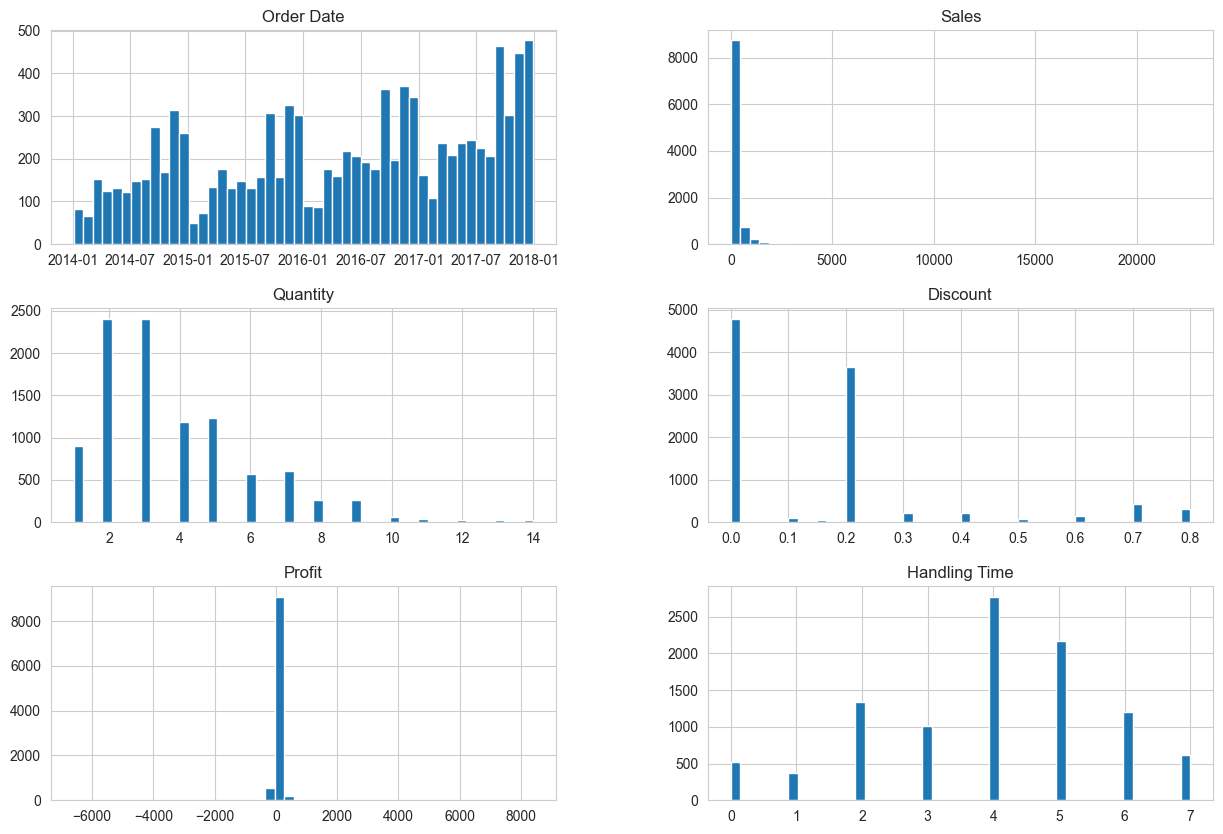

In [51]:
df.hist(bins=48, figsize=(15,10))
plt.show()

### 3.2 Wykrywanie outlierów

In [52]:
def outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr 
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

report = []
for col in numeric_columns:
    mask = outliers(df[col])
    report.append({"variable": col, "outliers_count": int(mask.sum()),
                   "percent": round(100 * mask.mean(), 2)})
pd.DataFrame(report)

,variable,outliers_count,percent
0,Sales,1167,11.68
1,Profit,1881,18.82
2,Discount,856,8.57
3,Quantity,170,1.70
4,Handling Time,0,0.00


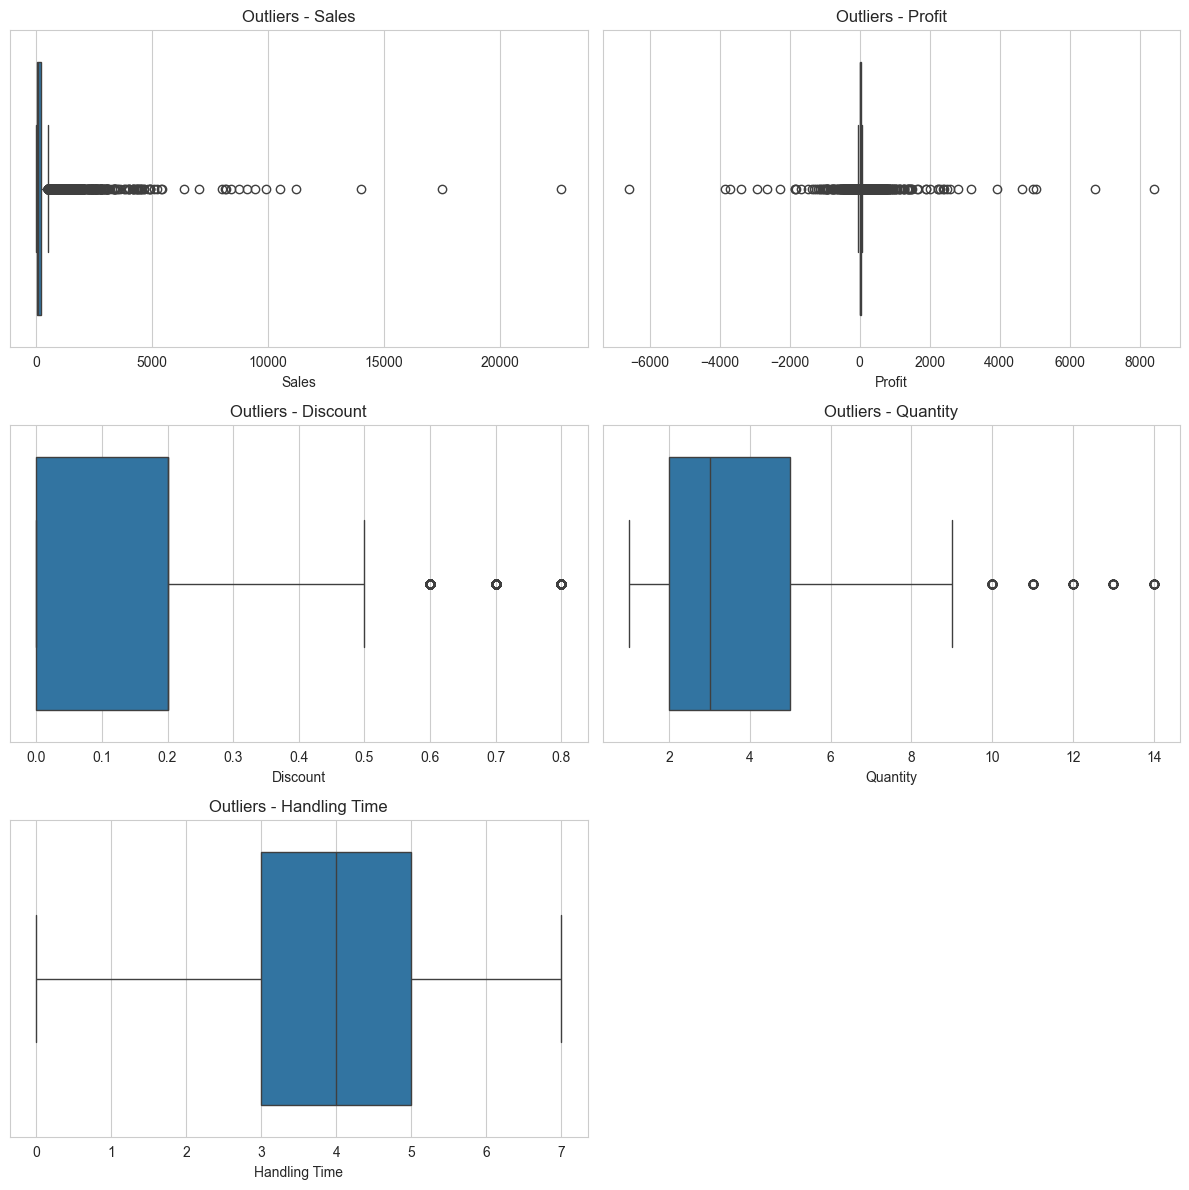

In [53]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

sns.boxplot(x=df["Sales"], ax=axes[0, 0])
axes[0, 0].set_title("Outliers - Sales")

sns.boxplot(x=df["Profit"], ax=axes[0, 1])
axes[0, 1].set_title("Outliers - Profit")

sns.boxplot(x=df["Discount"], ax=axes[1, 0])
axes[1, 0].set_title("Outliers - Discount")

sns.boxplot(x=df["Quantity"], ax=axes[1, 1])
axes[1, 1].set_title("Outliers - Quantity")

sns.boxplot(x=df["Handling Time"], ax=axes[2, 0])
axes[2, 0].set_title("Outliers - Handling Time")

axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()



**Wniosek**: outlierów jest wiele, zwłaszcza w Sales i Profit. Promuje to stosowanie mediany, a nie średniej, kwartyli, a nie odchylenia standardowego i testów rangowych zamiast parametrycznych (np. Mann-Whitney U zamiast testu t, Spearman zamiast Pearsona)

### 3.3 Sezonowość (Order Date)

Histogram Order Date ujawnia powtarzalny wzór roczny w liczbie zamówień. Wyciągamy z daty cechy kalendarzowe (miesiąc), a następnie wizualizujemy sezonowość i rozkładamy szereg na trend, sezon i resztę.

In [54]:
# calendar features
df["order_month"] = df["Order Date"].dt.month

df[["Order Date", "order_month"]].head()

,Order Date,order_month
0,2016-11-08,11
1,2016-11-08,11
2,2016-06-12,6
3,2015-10-11,10
4,2015-10-11,10


Wizualizacja sezonowości - po lewej liczba transakcji wg miesiąca kalendarzowego (zsumowana po latach, pokazuje cykl), po prawej szereg miesięczny w czasie (cykl nałożony na rosnący trend).

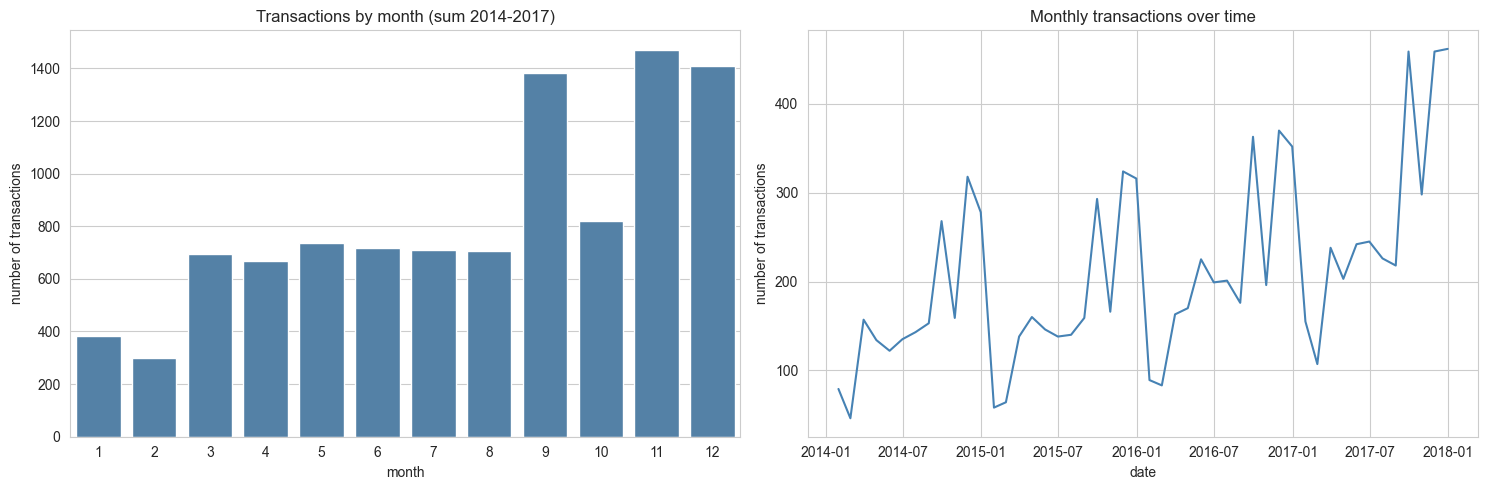

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# transactions per calendar month, summed over all years -> the yearly cycle
by_month = df.groupby("order_month").size()
sns.barplot(x=by_month.index, y=by_month.values, ax=axes[0], color="steelblue")
axes[0].set_title("Transactions by month (sum 2014-2017)")
axes[0].set_xlabel("month")
axes[0].set_ylabel("number of transactions")

# monthly transactions over time -> trend + seasonality together
monthly_orders = df.set_index("Order Date").resample("ME").size()
axes[1].plot(monthly_orders.index, monthly_orders.values, color="steelblue")
axes[1].set_title("Monthly transactions over time")
axes[1].set_xlabel("date")
axes[1].set_ylabel("number of transactions")

plt.tight_layout()
plt.show()

Dekompozycja sezonowa rozkłada szereg miesięczny na trzy składowe: trend (długoterminowy wzrost), sezon (powtarzalny cykl 12-miesięczny) i resztę (szum). Formalnie potwierdza to wzór dostrzeżony na histogramie.

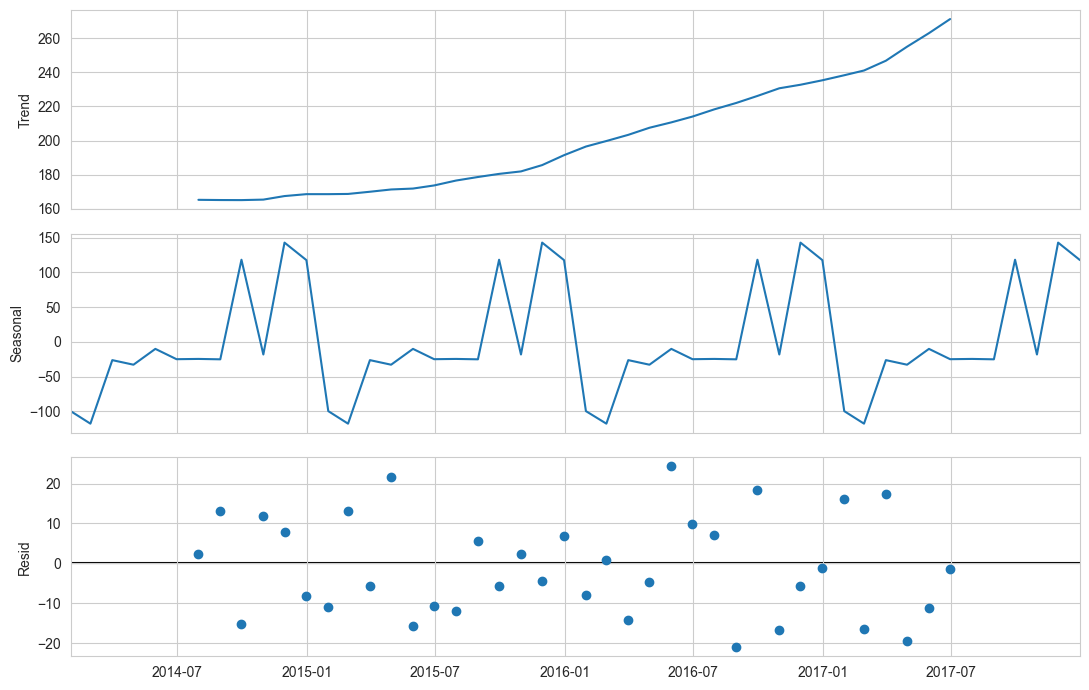

In [56]:
# split the monthly transaction series into trend + seasonality + residual
monthly_orders = df.set_index("Order Date").resample("ME").size()
decomposition = sm.tsa.seasonal_decompose(monthly_orders, model="additive", period=12)
fig = decomposition.plot(observed=False, trend=True, resid=True, weights=False, seasonal=True)
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.show()

**Wniosek**: liczba zamówień ma wyraźną sezonowość - szczyty we wrześniu, listopadzie i grudniu, dołki w styczniu i lutym - nałożoną na rosnący trend rok do roku.

### 3.4 Sezonowość: wolumen, wartość i marża

Histogram Order Date pokazał cykl roczny w liczbie zamówień. Sprawdzamy, czy ten sam rytm mają sprzedaż i zysk. Indeks sezonowy = suma miesięczna podzielona przez średnią miesięczną (1.0 = przeciętny miesiąc), liczony osobno dla liczby transakcji, sprzedaży i zysku.

                count     Sales    Profit
order_month                              
1            0.457520  0.495924  0.382716
2            0.360252  0.312164  0.431325
3            0.835785  1.071028  1.198063
4            0.800961  0.718253  0.485997
5            0.882618  0.809931  0.938992
6            0.861003  0.797862  0.891835
7            0.852597  0.769229  0.579563
8            0.847793  0.830908  0.912413
9            1.660763  1.607283  1.544259
10           0.983488  1.046565  1.331691
11           1.766437  1.841394  1.486060
12           1.690784  1.699460  1.817087


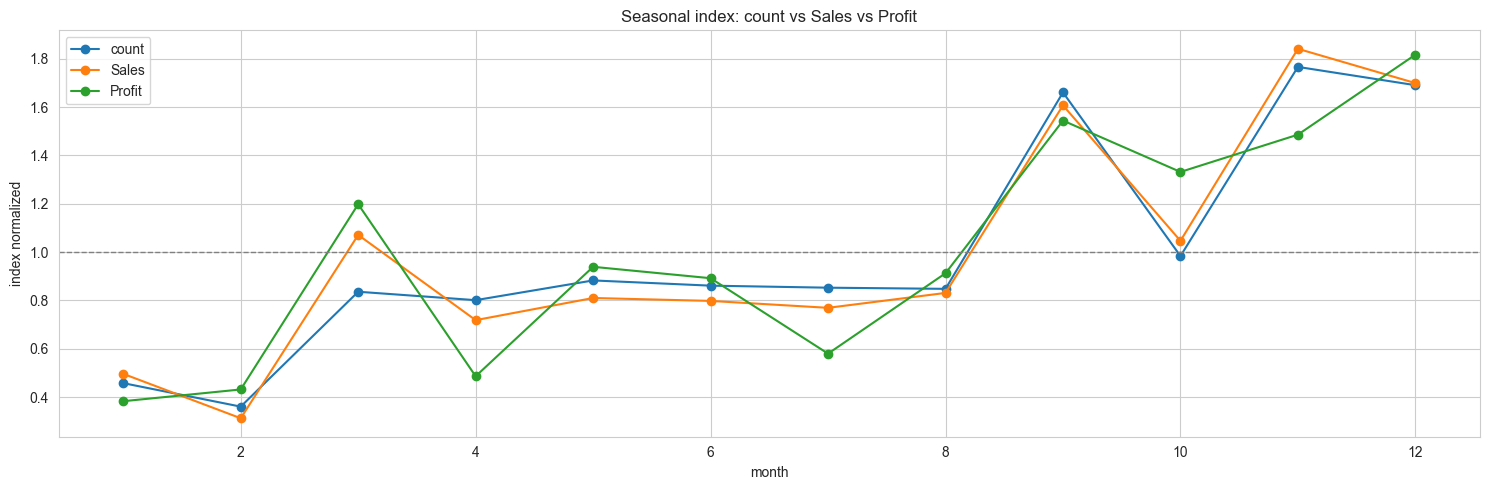

In [57]:
# seasonal index = monthly total / overall monthly mean (1.0 = an average month)
monthly_idx = pd.DataFrame({
    "count":  df.groupby("order_month").size(),
    "Sales":  df.groupby("order_month")["Sales"].sum(),
    "Profit": df.groupby("order_month")["Profit"].sum(),
})
monthly_idx = monthly_idx / monthly_idx.mean()

print(monthly_idx)

fig, axes = plt.subplots(figsize=(15, 5))
monthly_idx.plot(marker="o", ax=axes)
axes.axhline(1.0, color="gray", ls="--", lw=1)
axes.set_title("Seasonal index: count vs Sales vs Profit")
axes.set_xlabel("month")
axes.set_ylabel("index normalized")

plt.tight_layout()
plt.show()

Liczba transakcji, sprzedaż i zysk poruszają się w zbliżonym rytmie, ale nie idealnie - np. kwiecień i lipiec mają względnie więcej transakcji niż zysku.

## Etap 4 - Analiza

Statystyki, wizualizacje rozkładów oraz testy statystyczne (Mann-Whitney, Chi-kwadrat).

### 4.1 Statystyki zmiennych numerycznych

Wizualizacje dystrybucji zmiennych numerycznych

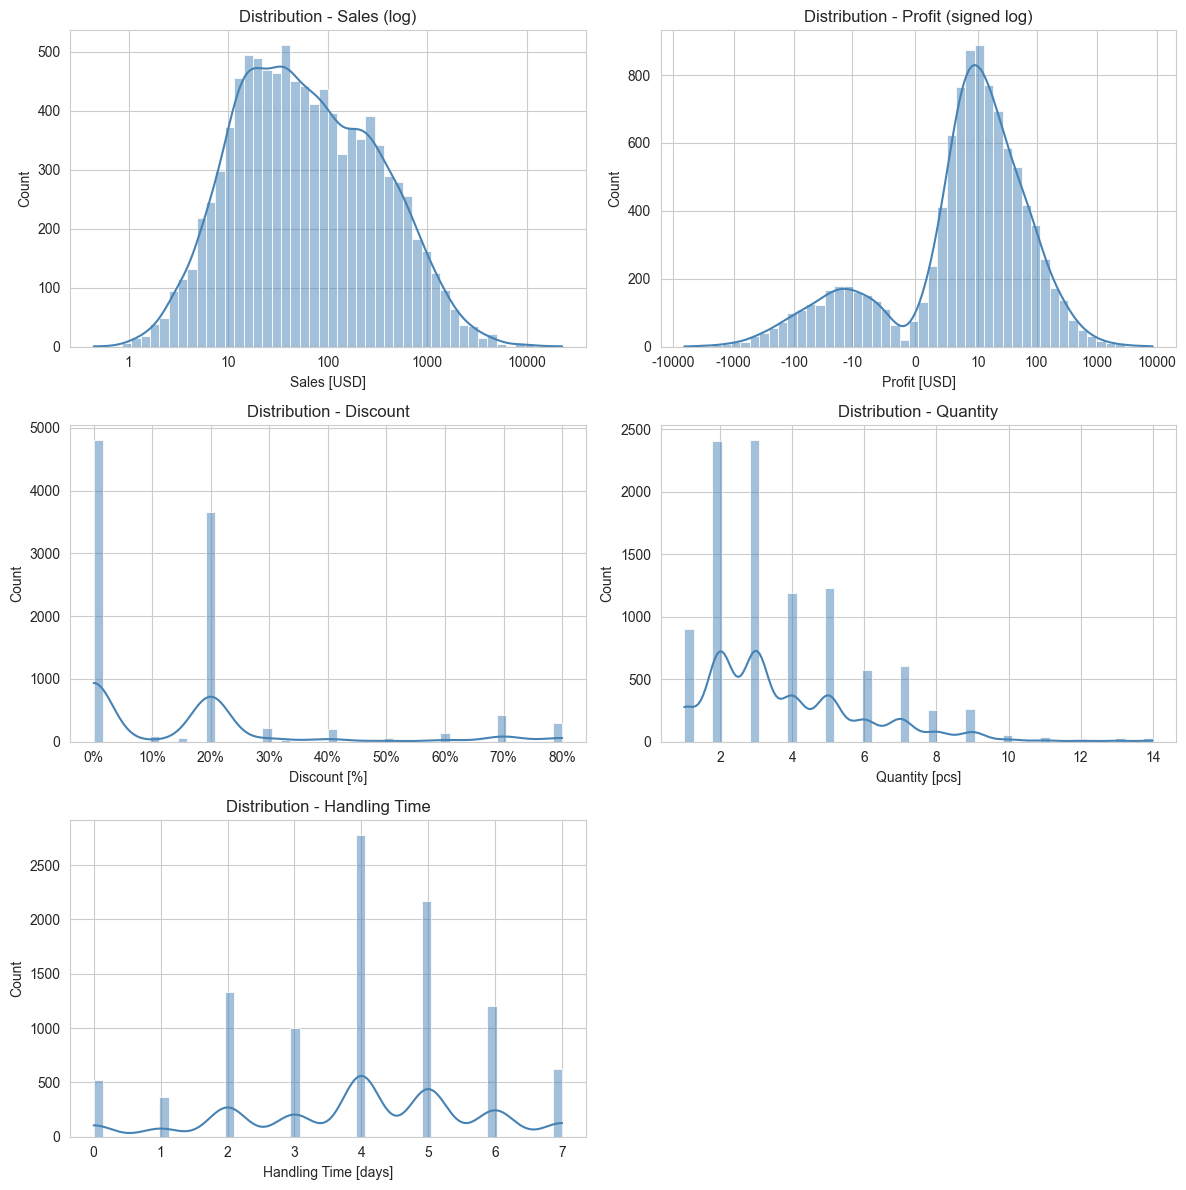

In [58]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

sns.histplot(df["Sales"], kde=True, ax=axes[0, 0], color="steelblue", bins=50, log_scale=True)
axes[0, 0].set_title("Distribution - Sales (log)")
axes[0, 0].set_xlabel("Sales [USD]")
#show plain numbers (10, 1000, ...) instead of powers of 10
axes[0, 0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}" if v < 1 else f"{v:.0f}"))

signed_log_profit = np.sign(df["Profit"]) * np.log10(1 + np.abs(df["Profit"]))   #handles negatives & zero
sns.histplot(signed_log_profit, kde=True, ax=axes[0, 1], color="steelblue", bins=50)
axes[0, 1].set_title("Distribution - Profit (signed log)")
#label x-axis with real Profit values
profit_ticks = [-10000, -1000, -100, -10, 0, 10, 100, 1000, 10000]
axes[0, 1].set_xticks([np.sign(v) * np.log10(1 + abs(v)) for v in profit_ticks])
axes[0, 1].set_xticklabels([f"{v}" for v in profit_ticks])
axes[0, 1].set_xlabel("Profit [USD]")


sns.histplot(df["Discount"], kde=True, ax=axes[1, 0], color="steelblue", bins=50)
axes[1, 0].set_title("Distribution - Discount")
axes[1, 0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1, 0].set_xlabel("Discount [%]")

sns.histplot(df["Quantity"], kde=True, ax=axes[1, 1], color="steelblue", bins=50)
axes[1, 1].set_title("Distribution - Quantity")
axes[1, 1].set_xlabel("Quantity [pcs]")

sns.histplot(df["Handling Time"], kde=True, ax=axes[2, 0], color="steelblue", bins=50)
axes[2, 0].set_title("Distribution - Handling Time")
axes[2, 0].set_xlabel("Handling Time [days]")

axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()

Skośność i kurtoza zmiennych numerycznych. 


In [59]:
desc = df[numeric_columns].describe().T
# add skewness and kurtosis to 'describe' table
desc["skewness"] = [stats.skew(df[c]) for c in numeric_columns]
desc["kurtosis"] = [stats.kurtosis(df[c], fisher=True) for c in numeric_columns]
desc

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Sales,9993.0,229.852846,623.276074,0.444,17.280,54.480,209.940,22638.480,12.970194,305.128443
Profit,9993.0,28.660971,234.271476,-6599.978,1.731,8.671,29.364,8399.976,7.559901,396.951098
Discount,9993.0,0.156188,0.206457,0.000,0.000,0.200,0.200,0.800,1.684256,2.408171
Quantity,9993.0,3.789753,2.225149,1.000,2.000,3.000,5.000,14.000,1.278224,1.989986
Handling Time,9993.0,3.958171,1.747654,0.000,3.000,4.000,5.000,7.000,-0.421231,-0.288284


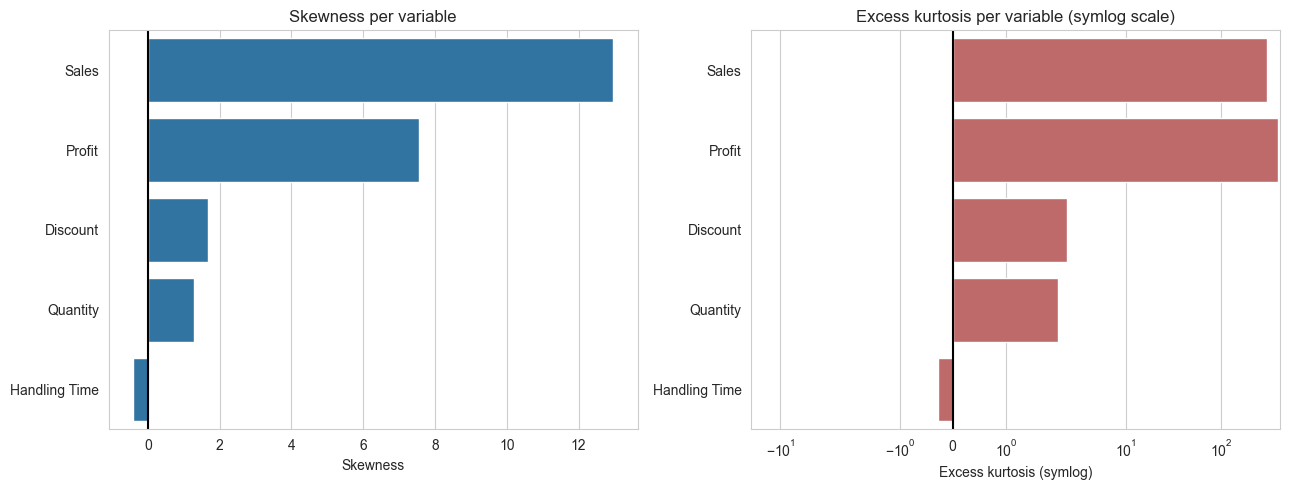

In [60]:
# Graphical view of the skewness and kurtosis
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=desc["skewness"], y=numeric_columns, ax=axes[0])
axes[0].axvline(0, color="black",)
axes[0].set_title("Skewness per variable")
axes[0].set_xlabel("Skewness")

sns.barplot(x=desc["kurtosis"], y=numeric_columns, ax=axes[1], color="indianred")
axes[1].axvline(0, color="black")
axes[1].set_xscale("symlog")  # Sales/Profit kurtosis is ~300-400; symlog keeps small bars visible
axes[1].set_title("Excess kurtosis per variable (symlog scale)")
axes[1].set_xlabel("Excess kurtosis (symlog)")

plt.tight_layout()
plt.show()

Rozkłady Sales i Profit są wyraźnie skośne i mają grube ogony (kurtozę). Ma to związek m.in. z dużą ilością outlierów. 
Konsekwencją jest unikanie, w dalszej analizie, narzędzi wymagających rozkładów normalnych.

### 4.2 Statystyki zmiennych kategorycznych

In [61]:

for c in categorical_columns:
    print(f"--- {c} ---")
    print(df[c].value_counts(normalize=True).round(3))
    print()

--- Category ---
Category
Office Supplies    0.603
Furniture          0.212
Technology         0.185
Name: proportion, dtype: float64

--- Segment ---
Segment
Consumer       0.519
Corporate      0.302
Home Office    0.178
Name: proportion, dtype: float64

--- Region ---
Region
West       0.321
East       0.285
Central    0.232
South      0.162
Name: proportion, dtype: float64

--- Ship Mode ---
Ship Mode
Standard Class    0.597
Second Class      0.195
First Class       0.154
Same Day          0.054
Name: proportion, dtype: float64



Poniżej wykresy prezentujące liczność każdej zmiennej kategorycznej.

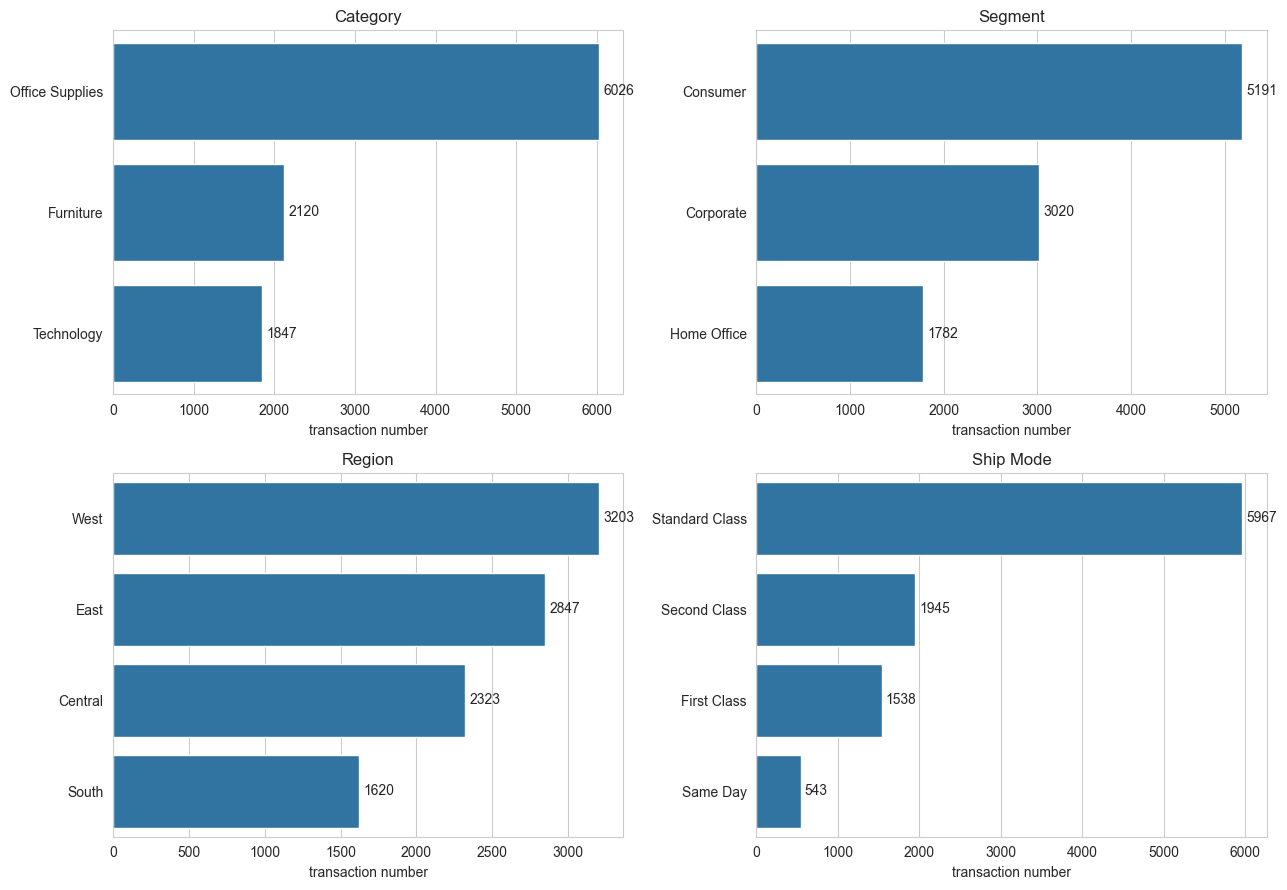

In [62]:
# Distribution of each categorical variable (counts)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), categorical_columns):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel("transaction number")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

### 4.3 Testy Manna-Whitneya - porównania parami między grupami Category

Ze względu na brak normalności rozkładów 'Sales' i 'Profit', ich silną skośność, grube ogony oraz dużą ilość outlierów, używamy testów rangowych, np. Manna-Whitneya.

Dla każdej zmiennej numerycznej, stosując test Manna-Whitneya, porównujemy parami 3 grupy Category. Stosujemy korektę Bonferroniego (p x liczba porównań), ponieważ nie robimy jednego testu, lecz wiele naraz: 3 pary x 5 zmiennych numerycznych = 15 testów. Przy 15 testach na poziomie alfa = 0,05 prawdopodobieństwo przynajmniej jednego fałszywego odkrycia (FWER) jest bardzo wysokie. Korekta skutecznie redukuje to ryzyko.


In [63]:
from itertools import combinations
categories = df["Category"].unique()
pairs = list(combinations(categories, 2))
n_comp = len(pairs) * len(numeric_columns)

results = []
for numeric_variable in numeric_columns:
    for category_var1, category_var2 in pairs:
        sample_series_var1 = df.loc[df["Category"] == category_var1, numeric_variable]
        sample_series_var2 = df.loc[df["Category"] == category_var2, numeric_variable]
        stat_u, p = stats.mannwhitneyu(sample_series_var1, sample_series_var2, alternative="two-sided")
        p_bonf = min(p * n_comp, 1.0)
        rank_biserial = 2 * stat_u / (len(sample_series_var1) * len(sample_series_var2)) - 1 #(-1..1) derived from U
        results.append({
            "variable": numeric_variable, "pair": f"{category_var1} vs {category_var2}",
            "U": round(stat_u, 1), "rank_biserial": round(rank_biserial, 3),
            "p": round(p, 4), "p_bonferroni": round(p_bonf, 4),
            "significant (p_bonferroni<0.05)": p_bonf < 0.05,
        })
mw_df = pd.DataFrame(results)
mw_df

,variable,pair,U,rank_biserial,p,p_bonferroni,significant (p_bonferroni<0.05)
0,Sales,Furniture vs Office Supplies,9721997.0,0.522,0.0000,0.0000,True
1,Sales,Furniture vs Technology,1869646.5,-0.045,0.0143,0.2140,False
2,Sales,Office Supplies vs Technology,2234534.5,-0.598,0.0000,0.0000,True
3,Profit,Furniture vs Office Supplies,6130008.5,-0.040,0.0057,0.0853,False
4,Profit,Furniture vs Technology,1378417.5,-0.296,0.0000,0.0000,True
5,Profit,Office Supplies vs Technology,3791697.5,-0.319,0.0000,0.0000,True
6,Discount,Furniture vs Office Supplies,7215892.5,0.130,0.0000,0.0000,True
7,Discount,Furniture vs Technology,2171802.0,0.109,0.0000,0.0000,True
8,Discount,Office Supplies vs Technology,5331518.0,-0.042,0.0025,0.0370,True
9,Quantity,Furniture vs Office Supplies,6341450.5,-0.007,0.6147,1.0000,False


W powyższej tabeli kolumna "significant" informuje, czy kategorie asortymentu (Category) z danej pary, dla danej zmiennej numerycznej, różnią się istotnie - pokazuje, że dystrybucje zmiennej w obu grupach Category są różne (mediany/przesunięcie rozkładu). 

Łatwo zauważyć, że dla ilości zamówionych sztuk (Quantity), oraz dla czasu obsługi zamówienia (Handling Time), nie występuje istotna różnica pomiędzy poszczególnymi asortymentami. Na wykresach poniżej, dla zmiennych Quantity i Handling Time, boxploty poszczególnych asortymentów są niemal identyczne. Innymi słowy żadna konkretna kategoria asortymentu nie ma związku statystycznego ani z zamawioną ilością, ani z czasem obsługi zamówienia. 

Kolumna "rank_biserial" to wielkość efektu - mówi, jak duża jest różnica między poszczególnymi grupami (asortymentami), niezależnie od istotności statystycznej (jaka część obserwacji asortymentu A, jest większa od obserwacji asortymentu B (-1 - żadna, 0 - połowa, 1 - wszystkie)).

**Boxploty rozkładów zmiennych numerycznych wg Category** - obrazują, co wykrywa test (outliery ukryte dla czytelności).

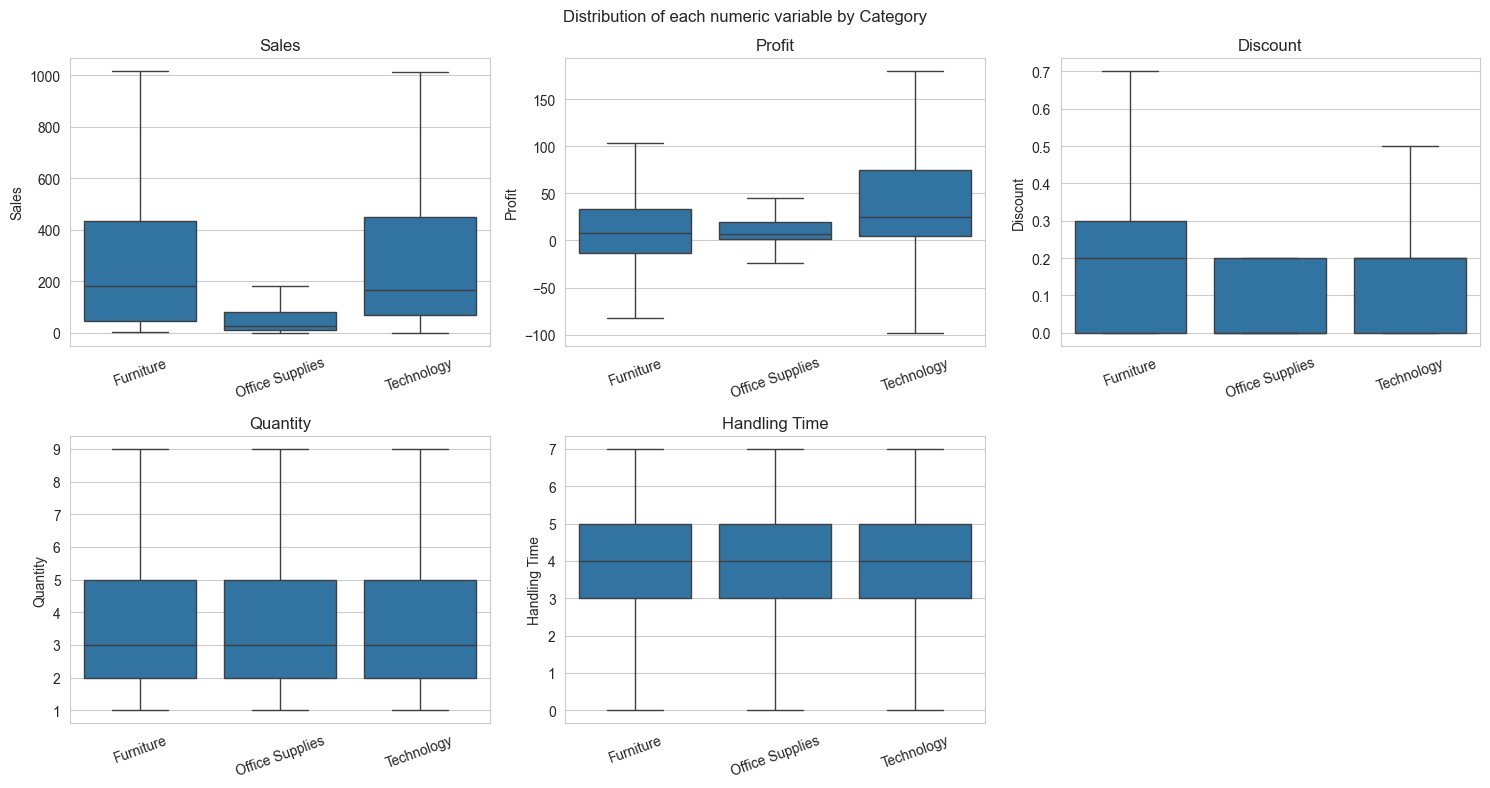

In [64]:
# distribution of each numeric variable by Category (outliers hidden)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_columns):
    sns.boxplot(data=df, x="Category", y=col, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
axes.ravel()[-1].set_visible(False)
fig.suptitle("Distribution of each numeric variable by Category")
plt.tight_layout()
plt.show()

### 4.4 Testy Chi-kwadrat - niezależność Category od innych zmiennych kategorycznych

**Weryfikacja założeń testu chi-kwadrat**

Założenie 1 - oczekiwana liczebność E >= 5.   
E - liczba obserwacji, jakiej spodziewalibyśmy się w danej komórce tabeli, gdyby obie zmienne były niezależne.



In [65]:
# check chi-square assumption: expected counts (E) should be >= 5 in all cells
for other in ["Segment", "Region", "Ship Mode"]:
    table = pd.crosstab(df["Category"], df[other])
    _, _, _, expected = stats.chi2_contingency(table)
    print(f"Category vs {other}: min expected E = {expected.min():.1f}, "
          f"cells with E >= 5 = {(expected >= 5).mean() * 100:.0f}%")

Category vs Segment: min expected E = 329.4, cells with E >= 5 = 100%
Category vs Region: min expected E = 299.4, cells with E >= 5 = 100%
Category vs Ship Mode: min expected E = 100.4, cells with E >= 5 = 100%


Powyżej sprawdzamy warunek E >= 5 dla wszystkich trzech tabel.
We wszystkich tabelach minimalne E wynosi >100, a 100% komórek ma E >= 5 - założenie jest spełnione

Założenie 2 - niezależność obserwacji. Założenie jest formalnie naruszone.
Wiersze to pozycje zamówień (9993 wiersze, ale tylko ok. 5000 unikalnych zamówień i 793 klientów), więc pozycje z tego samego zamówienia są ze sobą skorelowane (dzielą Segment, Region, Ship Mode i klienta). Naruszenie niezależności (klastrowanie) działa zawsze w jedną stronę: zawyża istotność, a więc zaniża p. Nasze wyniki są jednak i tak nieistotne (poniżej obliczone p > 0,7). Skoro nawet z tym zaniżonym p test nie wykrył zależności, to wniosek "Category jest niezależna od Segment/Region/Ship Mode" jest bezpieczny.


In [66]:
chi_results = []
for other in ["Segment", "Region", "Ship Mode"]:
    table = pd.crosstab(df["Category"], df[other])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    chi_results.append({
        "pair": f"Category vs {other}",
        "chi2": round(chi2, 3), "p": round(p, 4),
        "dof": dof, "significant (alfa=0.05)": p < 0.05,
    })
chi_df = pd.DataFrame(chi_results)
chi_df

,pair,chi2,p,dof,significant (alfa=0.05)
0,Category vs Segment,1.551,0.8176,4,False
1,Category vs Region,3.675,0.7206,6,False
2,Category vs Ship Mode,3.609,0.7294,6,False


Wszystkie p-wartości są wysokie (> 0,7), więc nie ma podstaw do odrzucenia H0 - rozkład Segment, Region i Ship Mode jest niezależny od kategorii produktu (Category). Innymi słowy mix segmentów, regionów i sposobów wysyłki jest podobny we wszystkich kategoriach asortymentu.

## Etap 5 - Analiza korelacji

Badamy zależności między zmiennymi numerycznymi korelacją rang Spearmana (odporną na outliery, których mamy wiele w naszym zbiorze danych).

### 5.1 Korelacja Spearmana (zmienne numeryczne)

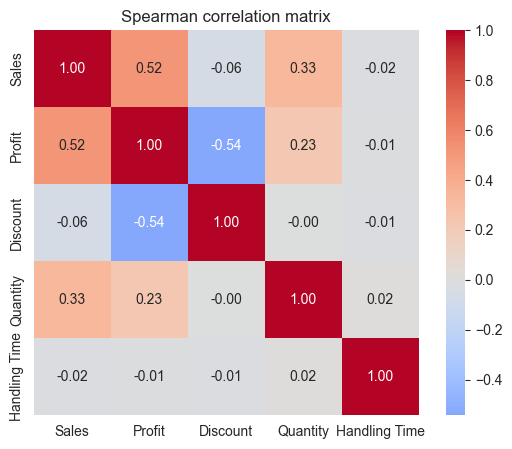

,Sales,Profit,Discount,Quantity,Handling Time
Sales,1.000,0.519,-0.057,0.328,-0.015
Profit,0.519,1.000,-0.543,0.234,-0.007
Discount,-0.057,-0.543,1.000,-0.001,-0.014
Quantity,0.328,0.234,-0.001,1.000,0.016
Handling Time,-0.015,-0.007,-0.014,0.016,1.000


In [67]:
spearman = df[numeric_columns].corr(method="spearman")
plt.figure(figsize=(7, 5))
sns.heatmap(spearman, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
plt.title("Spearman correlation matrix")
plt.show()
spearman.round(3)

Łatwo zauważyć, że najsilniej skorelowane (ujemnie) są zmienne "Discount" i "Profit", a także (dodatnio) "Sales" i "Profit". Jest to zgodne z intuicją - jeżeli udzielamy rabatu, to zysk prawdopodobnie maleje, a jeżeli mamy wysoką sprzedaż, to zysk rośnie.

## Etap 6 - ANOVA i ANCOVA


### 6.1 Sprawdzenie założeń ANOVA

In [68]:
# Levene test
groups = [df.loc[df["Category"] == c, "Profit"] for c in categories]
lev_stat, lev_p = stats.levene(*groups)

print(f"Levene: statistic = {lev_stat:.3f}, p-value = {lev_p:.4f}")
print(f"-> {'variances comparable' if lev_p > 0.05 else 'variances heterogeneous (assumption violated)'}")


Levene: statistic = 82.533, p-value = 0.0000
-> variances heterogeneous (assumption violated)


In [69]:
# D'Agostino-Pearson normality test
da_stat, da_p = stats.normaltest(df["Profit"])
print(f"D'Agostino-Pearson: statistic = {da_stat:.3f}, p-value = {da_p:.4f}")
print(f"-> {'distribution consistent with normal' if da_p > 0.05 else 'distribution deviates from normal (assumption violated)'}")

D'Agostino-Pearson: statistic = 14361.912, p-value = 0.0000
-> distribution deviates from normal (assumption violated)


Jednorodność wariancji (Levene): statystyka 82,5, p < 0,001 - wariancje zysku w trzech kategoriach są silnie niejednorodne (silnie heterogeniczne), założenie jest złamane.   
Normalność rozkładu (D'Agostino-Pearson): statystyka ok. 14360, p < 0,001 - rozkład zysku znacząco odbiega od normalnego.

Oba założenia klasycznej jednoczynnikowej ANOVA są naruszone. Dlatego wyniki klasycznej ANOVA traktujemy jako niewiarygodne i opieramy wnioskowanie na ANOVA Welcha (odporna na nierówność wariancji).

### 6.2 Jednoczynnikowa ANOVA

In [70]:
#classic ANOVA - showed just for fun ;) assumptions are not met, so we can not conclude on this
model_anova = smf.ols("Profit ~ C(Category)", data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Category),5.896782e+06,2.0,54.294334,3.527783e-24
Residual,5.424954e+08,9990.0,NaN,NaN


In [71]:
# Welch ANOVA - robust to unequal variances, good enough for our case 
# (sensitivity to outliers and non-normal distribution is compensated by big number of samples)
welch_anova = pg.welch_anova(data=df, dv="Profit", between="Category")
welch_anova

,Source,ddof1,ddof2,F,p_unc,np2
0,Category,2,3586.139136,24.067121,4.142924e-11,0.010753


In [72]:
# mean and median Profit per Category
df.groupby("Category")["Profit"].agg(["mean", "median", "count"]).round(2)

,mean,median,count
Category,,,
Furniture,8.71,7.78,2120
Office Supplies,20.33,6.88,6026
Technology,78.75,25.02,1847


**Wnioski - jednoczynnikowa ANOVA**

- Klasyczna ANOVA: F = 54,3, p < 0,001 - gdyby można było ją zastosować, na jej podstawie moglibyśmy odrzucić H0 o równości średnich; średni zysk różni się między kategoriami asortymentu.
- ANOVA Welcha (odporna na nierówne wariancje): F = 24,1, p < 0,001 - różnica utrzymuje się po uwzględnieniu heterogeniczności wariancji. Teraz możemy z całą odpowiedzialnością powiedzieć, że H0 została odrzucona.
- Średni zysk rośnie od Furniture (8,70) przez Office Supplies (20,33) do Technology (78,75) - Technology jest najbardziej dochodową kategorią.


### 6.3 Post-hoc Tukey HSD

         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
      Furniture Office Supplies  11.6179 0.1186 -2.1755 25.4114  False
      Furniture      Technology  70.0429    0.0 52.6564 87.4294   True
Office Supplies      Technology   58.425    0.0  43.897 72.9529   True
----------------------------------------------------------------------


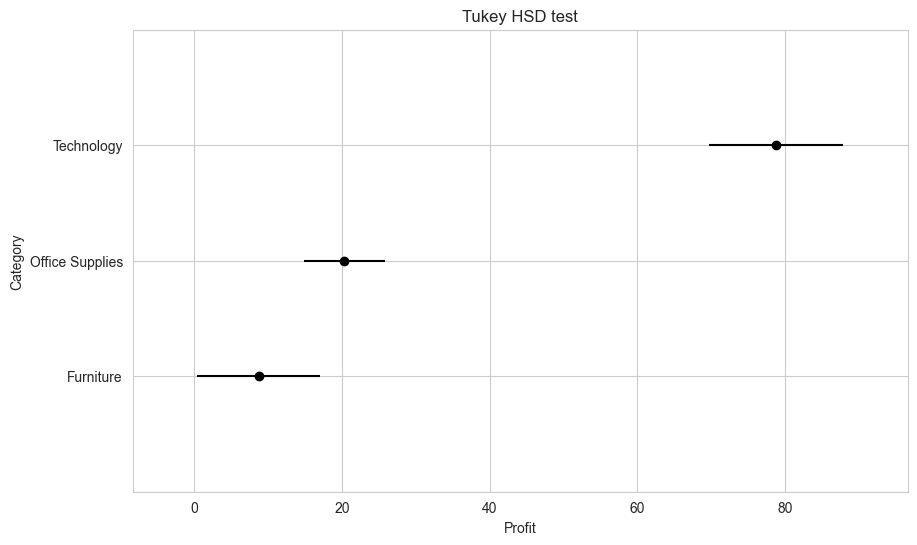

In [73]:
tukey = pairwise_tukeyhsd(df["Profit"], df["Category"], alpha=0.05)
print(tukey)
tukey.plot_simultaneous()
plt.title('Tukey HSD test')
plt.xlabel('Profit')
plt.ylabel('Category')
plt.show()

Test Tukey HSD wykazał, że aż 2 pary asortymentu różnią się istotnie statystycznie (p-adj < 0.05). Odrzucamy hipotezę H0 (mówiącą, że wszystkie średnie są równe).

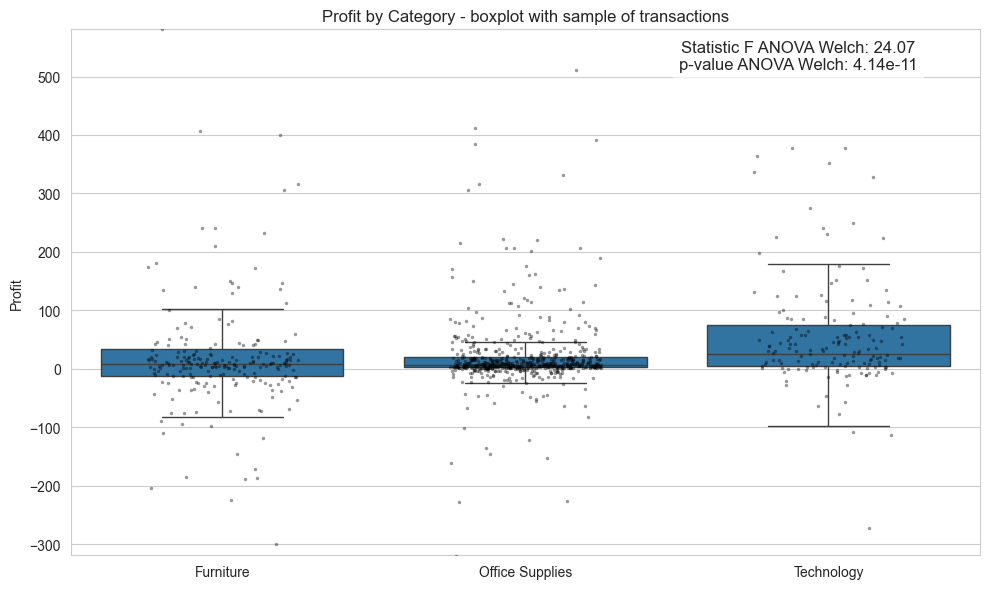

In [74]:
# boxplot + stripplot: Profit by Category, individual transactions overlaid
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="Category", y="Profit", showfliers=False, ax=ax)
sns.stripplot(data=df.sample(1000, random_state=77), x="Category", y="Profit",
              ax=ax, color="black", size=2.5, alpha=0.4, jitter=0.25)
ax.set_ylim(df["Profit"].quantile(0.01), df["Profit"].quantile(0.99))
ax.set_title("Profit by Category - boxplot with sample of transactions")
ax.set_xlabel("")
plt.tight_layout()

# add ANOVA results
anova_text = (
    f"Statistic F ANOVA Welch: {welch_anova['F'].iloc[0]:.2f}\n"
    f"p-value ANOVA Welch: {welch_anova['p_unc'].iloc[0]:.2e}"
)

plt.text(
    0.8, 0.95, anova_text,
    horizontalalignment='center',
    verticalalignment='center',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.5)
)

plt.show()

Boxplot z nałożonym stripplotem - pudełka pokazują rozkład zysku w kategoriach, a czarne punkty to pojedyncze transakcje (losowa próbka 1000, żeby wykres był czytelny).
Wyraźnie widać, że 'Office Supplies' jest kategorią o najniższych dochodach, w większości przypadków bliskich 0. 'Technology' przynosi najwyższe zyski, ale ma także najmniej zagęszczone próbki (wąsy wyznaczające wartości typowe są najszersze ze wszystkich 3 kategorii).

### 6.4 ANCOVA (Profit ~ Category + Sales) - weryfikacja założeń

ANCOVA (Profit ~ Category + Sales) opiera się na kilku założeniach. Najważniejsze i charakterystyczne dla niej to równoległość nachyleń regresji: wpływ kowariaty Sales na Profit musi być taki sam w każdej kategorii. Drugie istotne to niezależność kowariaty od grup (Sales nie powinno systematycznie różnić się między kategoriami). Sprawdzamy je przed dopasowaniem modelu.

In [75]:
# homogeneity of regression slopes: Category x Sales interaction
model_interaction = smf.ols("Profit ~ C(Category) * Sales", data=df).fit()
interaction_p = sm.stats.anova_lm(model_interaction, typ=2).loc["C(Category):Sales", "PR(>F)"]
print(f"Category x Sales interaction: p = {interaction_p:.2e}")
print("-> slopes NOT parallel: assumption violated" if interaction_p < 0.05 else "-> slopes parallel: assumption met")
print()
print("Sales -> Profit slope within each Category:")
for cat in df["Category"].unique():
    sub = df[df["Category"] == cat]
    slope = np.polyfit(sub["Sales"], sub["Profit"], 1)[0]
    print(f"  {cat:16s} slope = {slope:.3f}")
print()
print("Mean Sales per Category:")
print(df.groupby("Category")["Sales"].mean().round(1).to_string())

Category x Sales interaction: p = 6.66e-69
-> slopes NOT parallel: assumption violated

Sales -> Profit slope within each Category:
  Furniture        slope = 0.047
  Office Supplies  slope = 0.238
  Technology       slope = 0.195

Mean Sales per Category:
Category
Furniture          349.9
Office Supplies    119.3
Technology         452.7


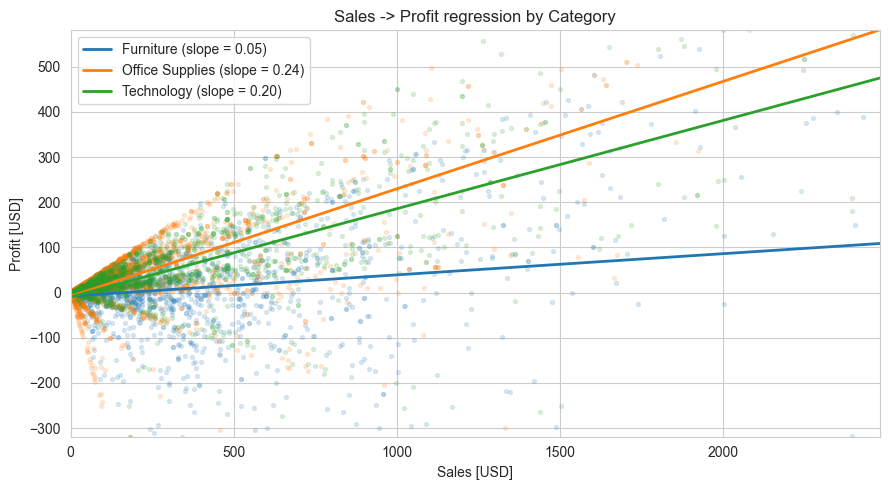

In [76]:
# Sales -> Profit regression line per Category
fig, ax = plt.subplots(figsize=(9, 5))
x_line = np.linspace(0, df["Sales"].quantile(0.99), 100)
for cat, color in zip(df["Category"].unique(), ["tab:blue", "tab:orange", "tab:green"]):
    sub = df[df["Category"] == cat]
    slope, intercept = np.polyfit(sub["Sales"], sub["Profit"], 1)
    ax.scatter(sub["Sales"], sub["Profit"], s=8, alpha=0.15, color=color)
    ax.plot(x_line, slope * x_line + intercept, color=color, lw=2, label=f"{cat} (slope = {slope:.2f})")
ax.set_xlim(0, df["Sales"].quantile(0.99))
ax.set_ylim(df["Profit"].quantile(0.01), df["Profit"].quantile(0.99))
ax.set_xlabel("Sales [USD]")
ax.set_ylabel("Profit [USD]")
ax.set_title("Sales -> Profit regression by Category")
ax.legend()
plt.tight_layout()
plt.show()

**Założenia ANCOVA nie są spełnione - modelu nie liczymy.**

- Równoległość nachyleń: ANCOVA wymaga, żeby w każdej kategorii dolar sprzedaży dawał tyle samo zysku. Tak nie jest: z 1 dolara sprzedaży zostaje ok. 24 centów zysku w Office Supplies, ok. 20 w Technology i tylko ok. 5 w Furniture. Test interakcji Category x Sales potwierdza, że te różnice są istotne (p ~ 0).
- Niezależność kowariaty: kategorie różnią się też samą wielkością sprzedaży (średnio: Office Supplies 119, Furniture 350, Technology 453), więc porównywanie ich "przy tej samej sprzedaży" oznaczałoby porównanie w warunkach, w których realnie prawie nie działają.

Skoro w każdej kategorii sprzedaż zamienia się w zysk w innym tempie, nie istnieje jedna "skorygowana o sprzedaż" różnica zysku między kategoriami - jej wielkość zależy od poziomu sprzedaży, przy którym porównujemy. Wniosek jest za to prosty: kategoria decyduje o tym, jak wydajnie sprzedaż zamienia się w zysk - najlepiej w Office Supplies, najsłabiej w Furniture.

## Etap 7 - Hipoteza badawcza i jej weryfikacja

Czy rabaty obniżają zysk transakcji.

### 7.1 Sformułowanie hipotezy

- **Pytanie badawcze**: Czy transakcje z udzielonym rabatem mają istotnie niższy zysk niż transakcje bez rabatu?
- **H0**: mediana Profit w grupie Discount > 0 jest **nie mniejsza** niż w grupie Discount == 0.
- **H1**: mediana Profit w grupie Discount > 0 jest **istotnie mniejsza**.
- **Poziom istotności**: alfa = 0.05.

### 7.2 Eksploracja wstępna

In [77]:
df["has_discount"] = np.where(df["Discount"] > 0, "With discount", "No discount")
print(df["has_discount"].value_counts())
print()
print(df.groupby("has_discount")["Profit"].describe().round(2))

has_discount
With discount    5195
No discount      4798
Name: count, dtype: int64

                count   mean     std      min   25%    50%    75%      max
has_discount                                                              
No discount    4798.0  66.90  257.06     0.00  6.58  16.00  50.37  8399.98
With discount  5195.0  -6.66  204.83 -6599.98 -8.08   3.34  14.69  3919.99


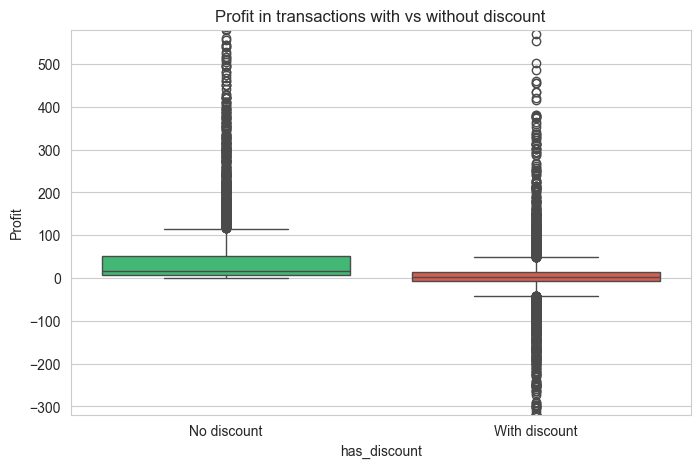

In [78]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="has_discount", y="Profit", data=df, palette=["#2ECC71", "#E74C3C"], 
            hue="has_discount", legend=False)

plt.title("Profit in transactions with vs without discount")
plt.ylim(df["Profit"].quantile(0.01), df["Profit"].quantile(0.99))
plt.show()

Już wstępne statystyki pokazują wyraźną różnicę: transakcje bez rabatu mają średni zysk ok. 67 i medianę 16, a transakcje z rabatem przynoszą średnio stratę (ok. -7, mediana 3,3).  
Grupy są podobnie liczne (4798 vs 5195), więc porównanie jest zrównoważone. 

### 7.3 Test Mann-Whitney (jednostronny)

In [79]:
profit_no = df.loc[df["Discount"] == 0, "Profit"]
profit_yes = df.loc[df["Discount"] > 0, "Profit"]

u_stat, p_val = stats.mannwhitneyu(profit_yes, profit_no, alternative="less")
print(f"Mann-Whitney U: statistic = {u_stat:.0f}")
print(f"p-value (one-sided, 'less') = {p_val:.6f}")
print(f"Decision at alfa = 0.05: {'REJECT H0' if p_val < 0.05 else 'DO NOT REJECT H0'}")

Mann-Whitney U: statistic = 6266788
p-value (one-sided, 'less') = 0.000000
Decision at alfa = 0.05: REJECT H0


Test odrzuca H0 (p < 0,001): zysk transakcji z rabatem jest istotnie niższy niż transakcji bez rabatu. Stosujemy wariant jednostronny, bo hipoteza wskazuje kierunek (rabat obniża zysk), oraz test rangowy - z powodu outlierów i braku normalności rozkładu zysku.

### 7.4 Dodatkowe potwierdzenie - korelacja Spearmana

In [80]:
rho, sp_p = stats.spearmanr(df["Discount"], df["Profit"])
print(f"Spearman rho(Discount, Profit) = {rho:.3f}")
print(f"p-value = {sp_p:.6f}")

Spearman rho(Discount, Profit) = -0.543
p-value = 0.000000


Korelacja Spearmana rho = -0,54 (p < 0,001) potwierdza wynik testu - rabat istotnie obniża zysk.  
Udzielając rabatów firma poświęca marżę. W praktyce, z biznesowego punktu widzenia, sugeruje to potrzebę:
- ograniczenia głębokich rabatów na produktach o niskiej marży bazowej
- prowadzenia dokładnej analizy progu rabatu, powyżej którego transakcje stają się nierentowne

## Etap 8 - Wnioski końcowe

- **Jakość danych**: zbiór jest kompletny (brak NaN, brak pustych stringów we wszystkich 21 oryginalnych kolumnach). Występują outliery (zwłaszcza w Sales i Profit), ale są informatywne, więc je pozostawiamy.
- **Najsilniej różnicujące kategorie produktów**: testy Manna-Whitneya (z wielkością efektu rank_biserial) pokazują, że między kategoriami Category istotnie różnią się Sales, Profit i Discount, natomiast Quantity i Handling Time - nie. Najsilniejsze efekty dotyczą Sales i Profit między Office Supplies a Technology.
- **Korelacje i zależności**:
  - Spearman: wyraźna dodatnia korelacja między Sales i Profit, wyraźna ujemna między Discount i Profit.
  - Niezależność kategorii: chi-kwadrat nie wykazał zależności Category od Segment, Region ani Ship Mode (wszystkie p > 0,7) - mix tych cech jest podobny we wszystkich kategoriach asortymentu.
- **ANOVA i ANCOVA**: średni Profit różni się istotnie między grupami Category (ANOVA Welcha F = 24,07 p < 0,001; założenia klasycznej ANOVA nie są spełnione, więc na jej podstawie nie wyciągamy wniosków).  
Klasycznej ANCOVA nie przeprowadzamy - jej kluczowe założenie (równoległość nachyleń) jest złamane: wpływ Sales na Profit silnie zależy od kategorii (interakcja Category x Sales p ~ 0; nachylenia 0,05 / 0,24 / 0,20). Sprzedaż przekłada się na zysk najmocniej w Office Supplies, a prawie wcale w Furniture.
- **Sezonowość (Order Date)**: liczba zamówień wykazuje wyraźny cykl roczny - szczyty we wrześniu, listopadzie i grudniu, dołki w styczniu i lutym - nałożony na rosnący trend rok do roku; potwierdza to dekompozycja szeregu miesięcznego na trend, sezon i resztę. Indeks sezonowy pokazuje, że sprzedaż i zysk poruszają się w zbliżonym rytmie co liczba transakcji, choć nie idealnie.
- **Hipoteza badawcza**: test Mann-Whitneya potwierdza, że transakcje z rabatem mają istotnie niższy zysk niż transakcje bez rabatu. Spearman wzmacnia ten wynik ujemną korelacją Discount-Profit. Rabaty obniżają rentowność - wymaga to dalszej analizy progów rabatowych.
